# Análisis de Precios de Airbnb

Análisis básico de datos de Airbnb con modelo de regresión lineal.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Cargar dataset de Airbnb
df = pd.read_csv('listings (1).csv.gz')

# Limpiar la columna de precios
df = df.dropna(subset=['price'])

# Corregir la expresión regular para quitar el símbolo '$' y comas
df['price'] = df['price'].replace({r'\$': '', ',': ''}, regex=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price'])

# Eliminar precios extremos (outliers básicos)
df = df[(df['price'] > 0) & (df['price'] < 1000)]

# Estadísticas básicas
promedio_precio = df['price'].mean()
mediana_precio = df['price'].median()

print(f'Promedio de precios: ${promedio_precio:.2f}')
print(f'Mediana de precios: ${mediana_precio:.2f}')
print(f'Total de listings: {len(df)}')

Promedio de precios: $613.28
Mediana de precios: $606.00
Total de listings: 10425


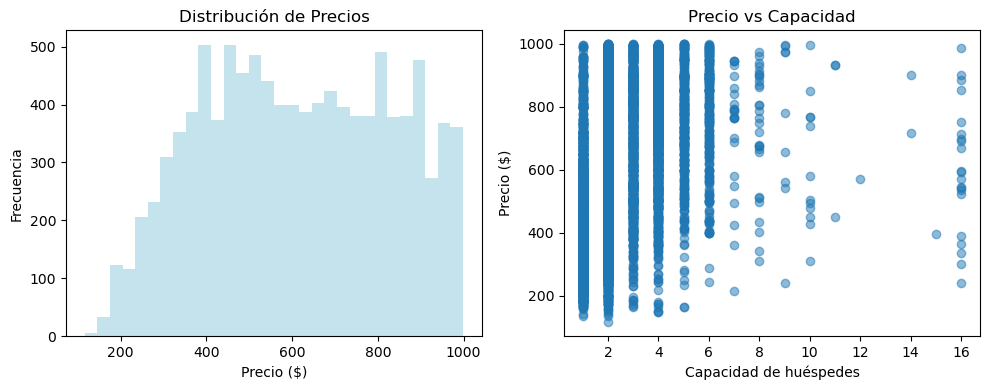

Variables disponibles para el modelo: ['accommodates', 'bedrooms', 'beds']


In [17]:
# Análisis exploratorio básico
plt.figure(figsize=(10, 4))

# Gráfico de distribución de precios
plt.subplot(1, 2, 1)
plt.hist(df['price'], bins=30, alpha=0.7, color='lightblue')
plt.title('Distribución de Precios')
plt.xlabel('Precio ($)')
plt.ylabel('Frecuencia')

# Identificar variables numéricas para el modelo
numeric_cols = ['accommodates', 'bedrooms', 'beds'] 
available_cols = [col for col in numeric_cols if col in df.columns]

if available_cols:
    # Limpiar datos para el modelo
    df_model = df[available_cols + ['price']].copy()
    df_model = df_model.dropna()
    
    # Mostrar correlación simple
    plt.subplot(1, 2, 2)
    if 'accommodates' in available_cols:
        plt.scatter(df_model['accommodates'], df_model['price'], alpha=0.5)
        plt.xlabel('Capacidad de huéspedes')
        plt.ylabel('Precio ($)')
        plt.title('Precio vs Capacidad')

plt.tight_layout()
plt.show()

print(f"Variables disponibles para el modelo: {available_cols}")


Modelo de regresión lineal: Precio vs accommodates
R² del modelo: 0.125
Coeficiente: 53.48
Intercepto: 484.94


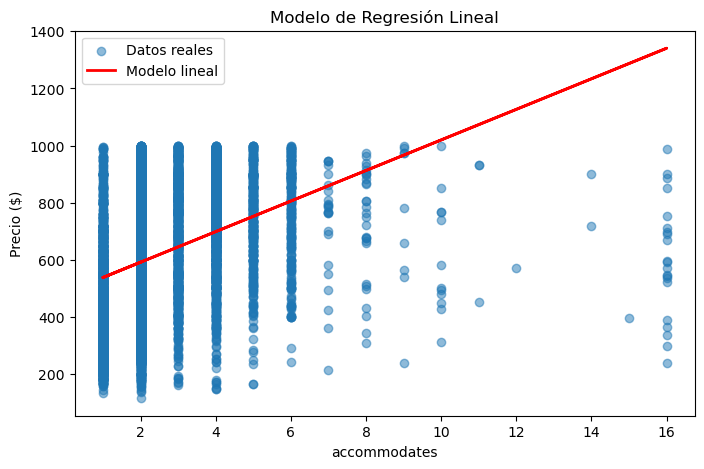

In [18]:
# Modelo de regresión lineal simple
if available_cols:
    # Usar solo la primera variable disponible para simplicidad
    X = df_model[available_cols[0]].values.reshape(-1, 1)
    y = df_model['price'].values
    
    # Crear y entrenar el modelo
    modelo = LinearRegression()
    modelo.fit(X, y)
    
    # Hacer predicciones
    predicciones = modelo.predict(X)
    
    # Calcular R²
    r2 = r2_score(y, predicciones)
    
    print(f"Modelo de regresión lineal: Precio vs {available_cols[0]}")
    print(f"R² del modelo: {r2:.3f}")
    print(f"Coeficiente: {modelo.coef_[0]:.2f}")
    print(f"Intercepto: {modelo.intercept_:.2f}")
    
    # Gráfico del modelo
    plt.figure(figsize=(8, 5))
    plt.scatter(X, y, alpha=0.5, label='Datos reales')
    plt.plot(X, predicciones, color='red', linewidth=2, label='Modelo lineal')
    plt.xlabel(f'{available_cols[0]}')
    plt.ylabel('Precio ($)')
    plt.title('Modelo de Regresión Lineal')
    plt.legend()
    plt.show()
    
else:
    print("No se encontraron variables adecuadas para el modelo")


In [19]:
# Conclusiones
print("=== CONCLUSIONES ===")
if available_cols and 'modelo' in locals():
    print(f"El modelo de regresión lineal usando '{available_cols[0]}' explica el {r2:.1%} de la variación en los precios.")
    if modelo.coef_[0] > 0:
        print(f"Por cada unidad adicional de {available_cols[0]}, el precio aumenta ${modelo.coef_[0]:.2f} en promedio.")
    else:
        print(f"Por cada unidad adicional de {available_cols[0]}, el precio disminuye ${abs(modelo.coef_[0]):.2f} en promedio.")
else:
    print("No se pudo crear el modelo de regresión.")


=== CONCLUSIONES ===
El modelo de regresión lineal usando 'accommodates' explica el 12.5% de la variación en los precios.
Por cada unidad adicional de accommodates, el precio aumenta $53.48 en promedio.


In [3]:
# Mostrar el valor más común de la columna 'room_type'
mas_comun_room_type = df['room_type'].mode()[0]
print(f'El tipo de habitación más común es: {mas_comun_room_type}')

El tipo de habitación más común es: Entire home/apt


In [4]:
# Mostrar las 10 alcaldías con más alojamientos
top_alcaldias = df['neighbourhood_cleansed'].value_counts().head(10)
print('Las 10 alcaldías con más alojamientos son:')
print(top_alcaldias)

Las 10 alcaldías con más alojamientos son:
neighbourhood_cleansed
Cuauhtémoc             10434
Miguel Hidalgo          3764
Benito Juárez           2482
Coyoacán                1362
Álvaro Obregón           799
Venustiano Carranza      752
Tlalpan                  582
Gustavo A. Madero        424
Iztacalco                389
Azcapotzalco             317
Name: count, dtype: int64


In [5]:
# Mostrar los 10 host_name con más alojamientos
top_hosts = df['host_name'].value_counts().head(10)
print('Las 10 personas con más alojamientos son:')
print(top_hosts)

Las 10 personas con más alojamientos son:
host_name
Alejandra     305
Alejandro     244
Juan          241
Blueground    225
Raul          225
Luis          214
Mr. W         201
Carlos        175
Eduardo       173
Jorge         172
Name: count, dtype: int64


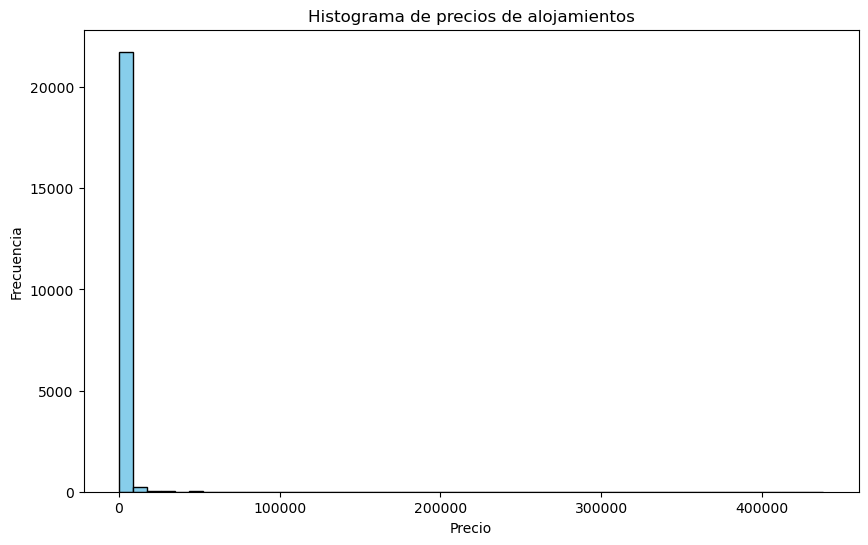

In [6]:
import matplotlib.pyplot as plt

# Graficar el histograma de precios
plt.figure(figsize=(10,6))
plt.hist(df['price'], bins=50, color='skyblue', edgecolor='black')
plt.title('Histograma de precios de alojamientos')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()

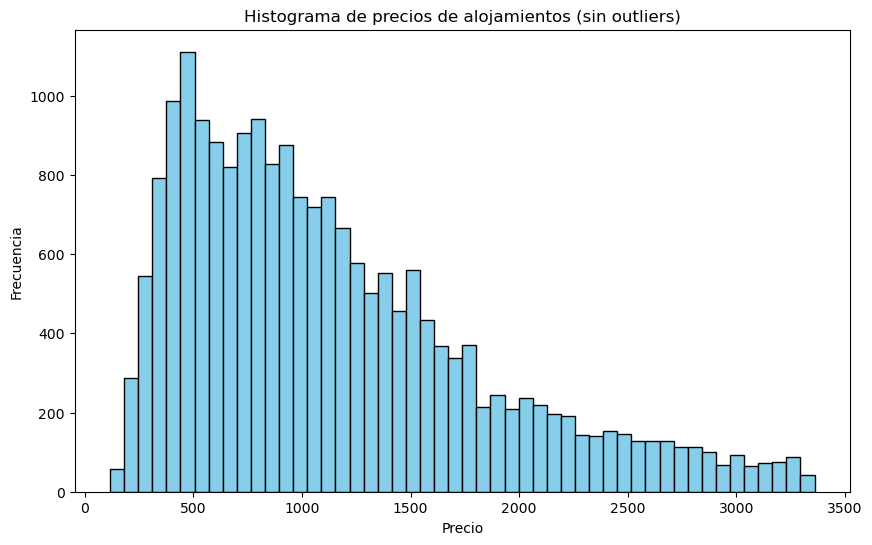

In [7]:
# Histograma de precios sin outliers (usando IQR)
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_sin_outliers = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

plt.figure(figsize=(10,6))
plt.hist(df_sin_outliers['price'], bins=50, color='skyblue', edgecolor='black')
plt.title('Histograma de precios de alojamientos (sin outliers)')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()

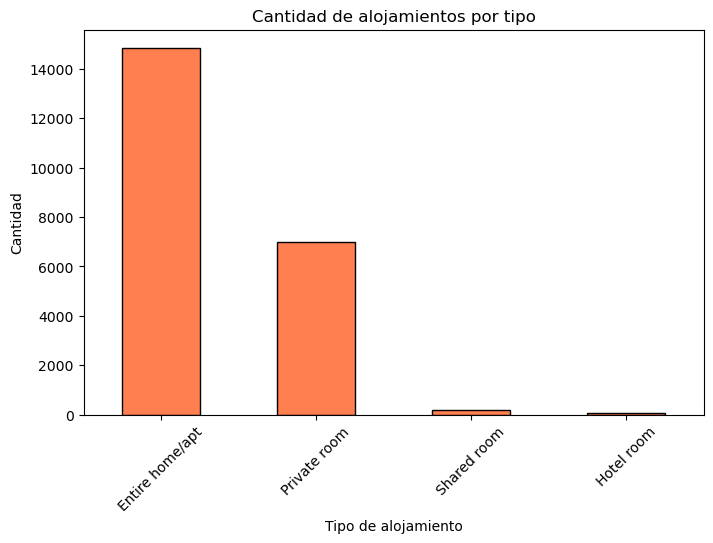

In [8]:
# Gráfica de barras: tipos de alojamiento vs cantidad
room_type_counts = df['room_type'].value_counts()
plt.figure(figsize=(8,5))
room_type_counts.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Cantidad de alojamientos por tipo')
plt.xlabel('Tipo de alojamiento')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()

In [9]:
import plotly.express as px

# Gráfica de distribución geográfica de precios con scattermapbox (sin bordes)
fig = px.scatter_mapbox(df, lat="latitude", lon="longitude", color="price",
                      color_continuous_scale="Viridis", size_max=8, zoom=10,
                      mapbox_style="open-street-map",
                      title="Distribución geográfica de precios de alojamientos")
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig.show()